In [279]:
from __future__ import annotations

import argparse
import json
import torch
from pathlib import Path
from typing import Dict, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==================== DEFAULT CONFIGURATION ====================
DEFAULT_RECORDS_DIR = Path("records")
DEFAULT_START_ROUND = 0       # inclusive
DEFAULT_END_ROUND = None      # exclusive, None = all rounds
DEFAULT_FL_METRIC = "acc"     # acc, loss, auc, f1
# ===============================================================


In [280]:
def load_protocol_data(protocol_dir: Path, start_round: int, end_round: Optional[int]) -> Tuple[pd.DataFrame, str, int]:
    """Load CSV and extract protocol name and param count."""
    df = pd.read_csv(protocol_dir / "compression_records.csv")

    # Filter rounds
    df = df[df["round_id"] >= start_round]
    if end_round is not None:
        df = df[df["round_id"] < end_round]

    # Get protocol name
    config_path = protocol_dir / "fl_config.json"
    protocol_name = protocol_dir.name
    if config_path.exists():
        with open(config_path) as f:
            protocol_name = json.load(f).get("codec", protocol_name)

    param_count = int(df["model_size"].iloc[0])
    return df, protocol_name, param_count


def plot_rate_distortion(all_protocols: Dict[str, pd.DataFrame], exclude=[]) -> None:
    """Plot WMAPE vs prior_rate with meta bits annotation."""
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_protocols)))
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']  # Different shapes

    # Store coordinates for arrow drawing
    coords = {}

    for idx, (name, df) in enumerate(all_protocols.items()):
        if name in exclude:
            print(f"⚠ Skipped {name}: excluded")
            continue
        # Compute averages
        wmape = df["wmape"].mean()
        if 'prior_rate' not in df.columns:
            print(f"⚠ Skipped {name}: missing prior_rate column")
            continue
        rate = df["prior_rate"].mean()

        if 'meta_data_size' in df.keys():
            meta_bits = (df["meta_data_size"].mean() * 8 * 1024 * 1024) / (df["model_size"].iloc[0])
        else:
            meta_bits = 0.0

        # Store coordinates for arrow drawing
        coords[name] = (rate, 10 * np.log10(wmape))

        ax.scatter(rate, 10 * np.log10(wmape), s=150, alpha=0.8, color=colors[idx],
                  marker=markers[idx % len(markers)], edgecolors="black",
                  linewidth=1, label=name, zorder=3)

        if meta_bits > 0.001:
            ax.annotate(f"{meta_bits:.3f}", xy=(rate, 10 * np.log10(wmape)), xytext=(8, -8),
                       textcoords="offset points", fontsize=8, alpha=0.6, style="italic")

    # Draw arrows for split_codec sequence
    split_sequence = ['2_split_codec', '3_split_codec', '5_split_codec']
    for i in range(len(split_sequence) - 1):
        if split_sequence[i] in coords and split_sequence[i+1] in coords:
            x1, y1 = coords[split_sequence[i]]
            x2, y2 = coords[split_sequence[i+1]]
            ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                       arrowprops=dict(arrowstyle='->', lw=1.5, alpha=0.5, color='gray'))

    # Draw arrows for codec to codec_binary pairs
    for name in coords:
        if not name.endswith('_binary'):
            binary_name = f"{name}_binary"
            if binary_name in coords:
                x1, y1 = coords[binary_name]
                x2, y2 = coords[name]
                ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                           arrowprops=dict(arrowstyle='->', lw=1.5, alpha=0.5, color='gray'))

    ax.set_xlabel("Prior Rate (bits/param)", fontsize=13, fontweight="bold")
    ax.set_ylabel("WMAPE (Distortion - 10db)", fontsize=13, fontweight="bold")
    ax.set_title("Rate-Distortion Curve", fontsize=14, fontweight="bold", pad=15)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", framealpha=0.95)
    ax.grid(True, alpha=0.25, linestyle="--")
    plt.tight_layout()
    plt.show()


def plot_fl_progress(all_protocols: Dict[str, pd.DataFrame], metric: str, exclude=[]) -> None:
    """Plot FL progress: thin worker lines + bold global line."""
    fig, ax = plt.subplots(figsize=(13, 6), dpi=100)
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_protocols)))
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']  # Different shapes

    for idx, (name, df) in enumerate(all_protocols.items()):
        if name in exclude:
            print(f"⚠ Skipped {name}: excluded")
            continue
        worker_col = f"test_{metric}"
        global_col = f"global_eval_{metric}"

        if worker_col not in df.columns or global_col not in df.columns:
            print(f"⚠ Skipped {name}: missing {metric} columns")
            continue

        # Workers: round_id as-is (starts at 0)
        for client_id in df["client_id"].unique():
            client_df = df[df["client_id"] == client_id]
            ax.plot(client_df["round_id"], client_df[worker_col],
                   color=colors[idx], alpha=0.12, linewidth=1, zorder=1)

        # Global: shift by -1 (evaluation happens before round updates)
        global_df = df.groupby("round_id")[global_col].first().reset_index()
        ax.plot(global_df["round_id"] - 1, global_df[global_col],
               color=colors[idx], alpha=0.70, linewidth=2.5,
               marker=markers[idx % len(markers)], markersize=6,
               markevery=1, label=name, zorder=2)

    ax.set_xlabel("Round", fontsize=13, fontweight="bold")
    ax.set_ylabel(metric.upper(), fontsize=13, fontweight="bold")
    ax.set_title(f"FL Progress: {metric.upper()}\n(thin=workers, bold=global)",
                fontsize=14, fontweight="bold", pad=15)
    ax.legend(loc="best", framealpha=0.95)
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.set_xlim(left=-1)  # Show pre-training global eval
    plt.tight_layout()
    plt.show()


def load_all_protocols(records_dir: Path, start_round: int=0, end_round: Optional[int]=None,
                       exclude: list = []) -> Dict[str, pd.DataFrame]:
    """Load all protocol CSVs from records_dir."""
    protocols = {}

    for run_dir in sorted(records_dir.iterdir()):
        if not run_dir.is_dir() or not (run_dir / "compression_records.csv").exists():
            continue

        try:
            df, name, _ = load_protocol_data(run_dir, start_round, end_round)

            if name in exclude or "wmape" not in df.columns:
                continue

            protocols[name] = df
            print(f"✓ {name:20s} | {df['round_id'].nunique()} rounds × {df['client_id'].nunique()} clients")

        except Exception as e:
            print(f"✗ Skipped {run_dir.name}: {e}")

    print(f"\nLoaded {len(protocols)} protocol(s)\n")
    return protocols


def print_meta_rates(all_protocols: Dict[str, pd.DataFrame]) -> None:
    """Print meta overhead in bits/param for each protocol."""
    print("\n" + "="*50)
    print("Meta Overhead (bits/param)")
    print("="*50)

    for name, df in all_protocols.items():
        if 'meta_data_size' not in df.columns:
            print(f"{name:20s} | No meta data")
            continue

        meta_bits = (df["meta_data_size"].mean() * 8 * 1024 * 1024) / (df["model_size"].iloc[0])
        print(f"{name:20s} | {meta_bits:8.4f}")

    print("="*50 + "\n")


def plot_rate_distortion_progress(all_protocols: Dict[str, pd.DataFrame], dist_col = 'wmape', exclude=[]) -> None:
    """Plot rate and distortion progress over rounds for all protocols."""
    fig, ax1 = plt.subplots(figsize=(13, 6), dpi=100)
    ax2 = ax1.twinx()  # Secondary y-axis for rate
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_protocols)))
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']  # Different shapes

    for idx, (name, df) in enumerate(all_protocols.items()):
        if name in exclude:
            print(f"⚠ Skipped {name}: excluded")
            continue
        if dist_col not in df.columns or "prior_rate" not in df.columns:
            print(f"⚠ Skipped {name}: missing {dist_col} or prior_rate columns")
            continue

        # Average across clients for each round
        round_data = df.groupby("round_id").agg({dist_col: "mean", "prior_rate": "mean"}).reset_index()

        # Distortion (WMAPE)
        ax1.plot(round_data["round_id"], round_data[dist_col],
                 color=colors[idx], alpha=0.70, linewidth=2.5,
                 marker=markers[idx % len(markers)], markersize=6,
                 markevery=1, label=f"{name}", zorder=2)

        # Rate (thin faded line)
        ax2.plot(round_data["round_id"], round_data["prior_rate"],
                 color=colors[idx], alpha=0.30, linewidth=1.5,
                 label=f"{name} (Rate)", zorder=1)

    ax1.set_xlabel("Round", fontsize=13, fontweight="bold")
    ax1.set_ylabel(f"{dist_col} (Distortion)", fontsize=13, fontweight="bold")
    ax2.set_ylabel("Prior Rate (bits/param)", fontsize=13, fontweight="bold")
    ax1.set_title("Rate and Distortion Progress Over Rounds", fontsize=14, fontweight="bold", pad=15)
    ax1.legend(loc="upper left", framealpha=0.5)
    # ax2.legend(loc="upper right", framealpha=0.5)
    ax1.grid(True, alpha=0.25, linestyle="--")
    plt.tight_layout()
    plt.show()


✓ identity             | 50 rounds × 5 clients
✓ 2_split_codec        | 50 rounds × 5 clients
✓ 3_split_codec        | 50 rounds × 5 clients
✓ 5_split_codec        | 50 rounds × 5 clients
✓ temporal_only        | 2 rounds × 5 clients
✓ temporal_only_binary | 1 rounds × 5 clients
✓ non_wz_learned       | 2 rounds × 5 clients
✓ non_wz_learned_binary | 1 rounds × 5 clients

Loaded 8 protocol(s)

⚠ Skipped identity: excluded


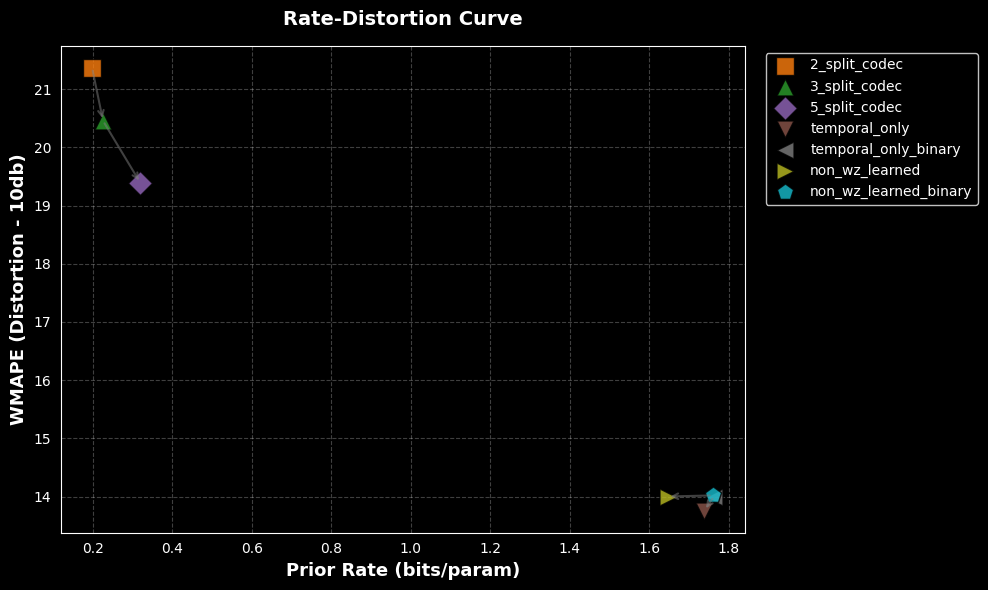

In [281]:
# Load all protocols from records directory
all_protocols = load_all_protocols(
    records_dir=Path("../records"),
    # start_round=10,           # Start from round 0
    # end_round=12,          # Include all rounds (or set a limit like 50)
    # exclude=['identity']     # Skip specific protocols
)

# print_meta_rates(all_protocols)

plot_rate_distortion(
    all_protocols,
    exclude=['identity']
)

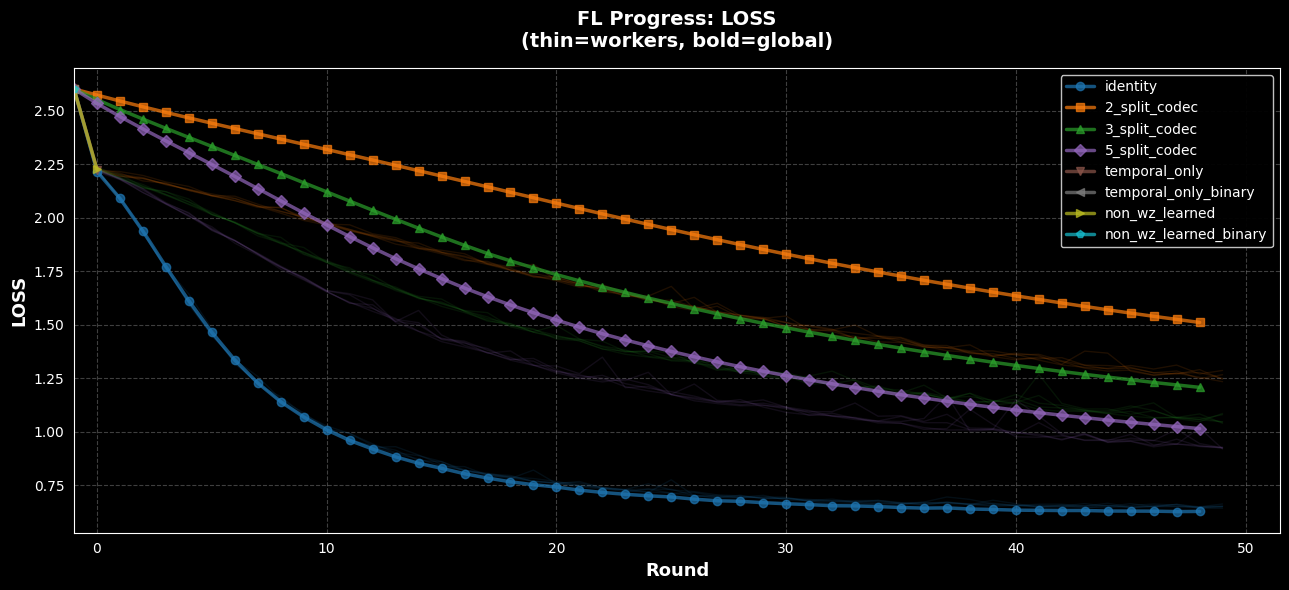

In [282]:
plot_fl_progress(all_protocols, metric="loss")

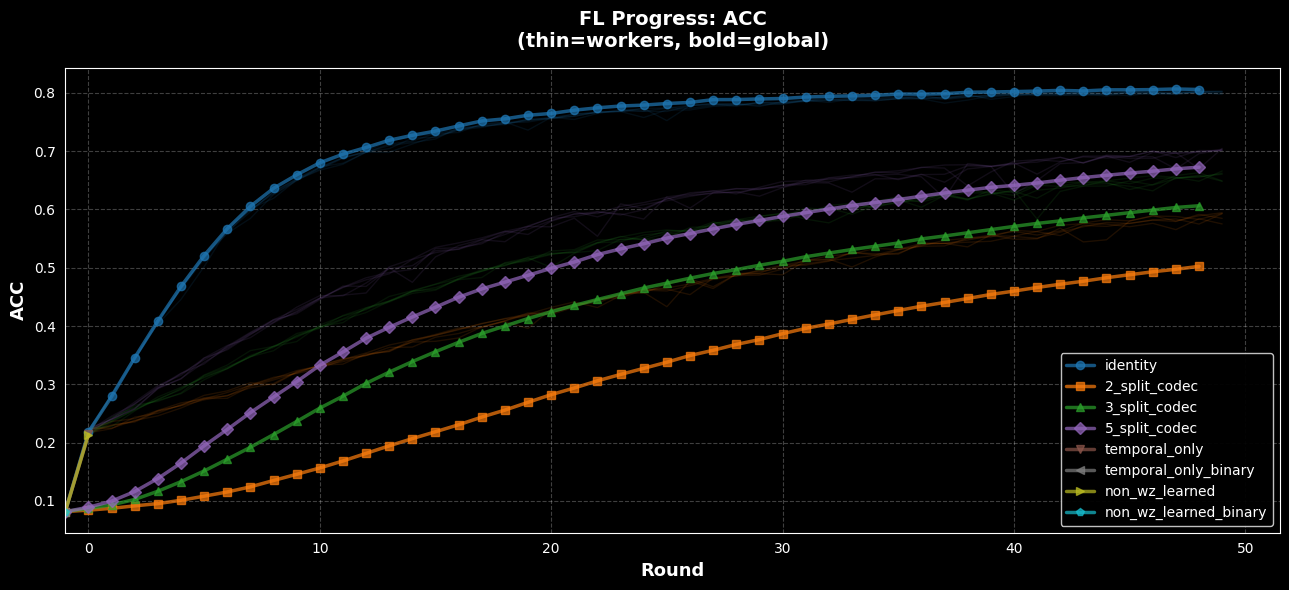

In [283]:
plot_fl_progress(all_protocols, metric="acc")

⚠ Skipped identity: excluded


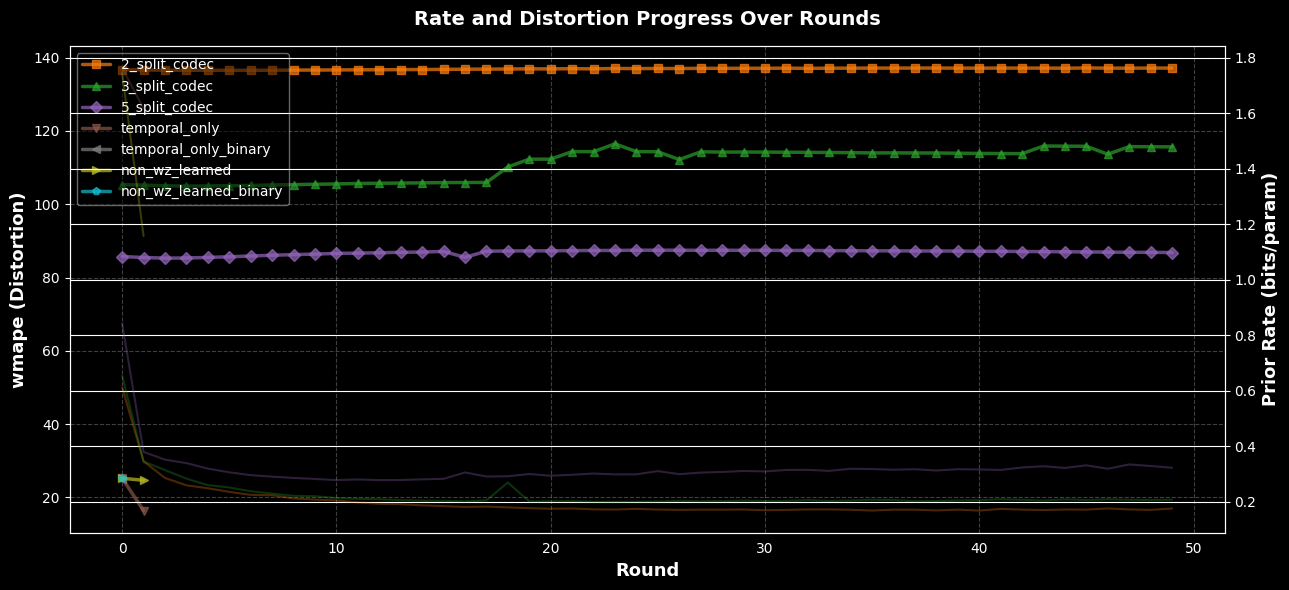

In [284]:
plot_rate_distortion_progress(
    all_protocols,
    exclude=['identity'],
    dist_col = 'wmape'
)